# Task 4 – Parameter optimization
Six optimization methods (TRF, L-BFGS-B, Nelder-Mead, GA, DE, DE→TRF) are compared on the same objective, trained on Charge 1C–4C and Discharge 1C, and checked on HPPC.

### 1. Setup
Loads the project package (`lfp_dfn`) and the optimization tools. Autoreload picks up changes in the `.py` files without restarting the kernel.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path

PROJECT_DIR = Path(r"K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\optim")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
warnings.filterwarnings("ignore")

from lfp_dfn import CellConfig, ProtocolConfig, CellModel
from lfp_dfn.optim import (OptimizationSettings, ParameterSpec, ParameterSpace,
                           build_training_set, CalibrationObjective, run_comparison,
                           print_summary, save_study, plot_convergence,
                           plot_parameter_comparison, plot_training_fit, run_hppc_check)

### 2. Configuration
Defines the optimization settings, the fixed cell parameters from manual tuning, the search space (bounds and log scaling) of the 6 parameters to optimize, and the manual start point.

###  Which optimization methods can be used

The DFN model is a black box for the optimizer: there is no formula for the gradient, and one evaluation (all five tests) takes around a minute. So a method has to work with few evaluations and without exact derivatives.

- **Gradient-based (TRF, L-BFGS-B):** gradients are estimated by finite differences (6 extra runs per gradient). They converge fast near the minimum but only find the valley they start in. TRF also uses the least-squares structure of the problem, which usually makes it the most efficient.
- **Gradient-free, local (Nelder-Mead):** compares objective values only, so it is robust to solver noise and failed simulations, but slower in more dimensions.
- **Gradient-free, global (GA, DE):** search the whole parameter box with a population. Less likely to get stuck in a local minimum, but they need many evaluations.
- **Hybrid (DE → TRF):** DE finds a good region first, then TRF refines it.

All six run with the same objective, start point, bounds, seed and evaluation budget, so the results can be compared fairly.

In [2]:
DATA_DIR = Path(r"K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\Data_dir") 
OUT_DIR  = PROJECT_DIR / "results" / "task4"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_TESTS   = ["Charge_1C", "Charge_2C", "Charge_3C", "Charge_4C", "Discharge_1C"]
OPTIMIZE_BETA = True

settings = OptimizationSettings(
    methods=("TRF", "L-BFGS-B", "Nelder-Mead", "GA", "DE", "DE->TRF"),
    budget=50,          # test run: 10
    fd_step=0.02,
    seed=0,
    v_scale=0.010,
    i_scale=0.10,
    penalty=10.0,
)
protocol = ProtocolConfig(v_cv=3.6)

# Fixed parameters (from manual tuning). Optimized fields are overwritten per evaluation.
base_cfg = CellConfig(
    x100=0.9082, graphite_ocp="Chen2020", use_soft_wall=True, k_wall=70,
    v_full_rest=3.447, du_charge=0.0, delta_p=0.15,
    eps_n=0.58, eps_p=0.374, beta_p=0.2, T_default_C=23.0,
)

# Search space: physical bounds, log10 scale except R_contact
space = ParameterSpace([
    ParameterSpec("D_n",       1e-15, 1e-12),
    ParameterSpec("D_p",       1e-19, 1e-15),
    ParameterSpec("k_j0_n",    0.1,   10.0),
    ParameterSpec("k_j0_p",    0.1,   10.0),
    ParameterSpec("R_contact", 0.0,   0.015, log=False),
    ParameterSpec("beta_p",    0.01,  1.0),
])
if not OPTIMIZE_BETA:
    space = space.without("beta_p")          # beta_p then stays at base_cfg.beta_p

# Start point = manual set
start = {"D_n": 1.5e-14, "D_p": 5.8e-18, "k_j0_n": 1.11, "k_j0_p": 1.14,
         "R_contact": 0.0, "beta_p": 0.2}

print(CellModel(base_cfg).summary())

Graphite OCP: Chen2020 | soft wall: True (k=70) | y100 = 0.0191 | dU_charge = 0 mV | Q_n = 2.907 Ah, Q_p = 3.292 Ah | R_contact = 0.00 mOhm


### 3. Training data and objective
Loads the five training tests, marks the CC and CV phases, and builds the objective J: CC voltage and CV current errors for the charge tests, voltage error for the discharge, with every test weighted equally.

###  Optimization pipeline

Input: the Charge 1C, 2C, 3C, 4C and Discharge 1C tests. The charge tests are simulated as CC-CV like the cycler; the discharge follows the measured current.

The objective J combines the CC-phase voltage error (per 10 mV) and the CV-phase current error (per 0.1 A) for each charge test, plus the voltage error of the discharge. Current is used in the CV phase because the voltage there is held at 3.6 V in both model and test, so the voltage error carries no information. Every test is weighted equally.

Six parameters are optimized (D_n, D_p, k_j0_n, k_j0_p, R_contact, β_p) in a normalized 0–1 space, on a log scale except R_contact. The fixed parameters come from the manual tuning in Task 3.

In [3]:
cases = build_training_set(TRAIN_TESTS, DATA_DIR, protocol, base_cfg.T_default_C)
for name, c in cases.items():
    print(f"{name:13s}: {c.data.duration_h * 60:6.1f} min, T = {c.data.T_C:.1f} °C, kind = {c.kind}")

objective = CalibrationObjective(base_cfg, space, cases, protocol, settings, verbose=True)

Charge_1C    :  102.3 min, T = 23.0 °C, kind = charge
Charge_2C    :   74.0 min, T = 23.0 °C, kind = charge
Charge_3C    :   64.4 min, T = 23.0 °C, kind = charge
Charge_4C    :   59.4 min, T = 23.0 °C, kind = charge
Discharge_1C :   64.7 min, T = 23.5 °C, kind = current


### 4. Run the optimization
Runs all six methods from the same start point with the same evaluation budget and logs every evaluation. This is the long-running cell.

### Results

Best method: **…**, with J reduced from **…** to **…** (**…** % lower). The optimized parameters are saved in `results/task4/optimized_parameters.json`, together with the comparison table and the full evaluation history. They are validated on HPPC in Task 5.

In [4]:
result = run_comparison(objective, start, settings)

Start J = 11.3035  (5.8 s per evaluation)
Estimated total time: 0.5 h (50 evals x 6 methods)

===== TRF =====
  [TRF] eval   1: J =  11.3035 (best  11.3035) | D_n=1.5e-14  D_p=5.8e-18  k_j0_n=1.11  k_j0_p=1.14  R_contact=1.5e-12  beta_p=0.2
  [TRF] eval   2: J =  11.2578 (best  11.2578) | D_n=1.58e-14  D_p=5.8e-18  k_j0_n=1.11  k_j0_p=1.14  R_contact=1.5e-12  beta_p=0.2
  [TRF] eval   3: J =  11.7767 (best  11.2578) | D_n=1.5e-14  D_p=6.29e-18  k_j0_n=1.11  k_j0_p=1.14  R_contact=1.5e-12  beta_p=0.2
  [TRF] eval   4: J =  11.8389 (best  11.2578) | D_n=1.5e-14  D_p=5.8e-18  k_j0_n=1.16  k_j0_p=1.14  R_contact=1.5e-12  beta_p=0.2
  [TRF] eval   5: J =  11.3381 (best  11.2578) | D_n=1.5e-14  D_p=5.8e-18  k_j0_n=1.11  k_j0_p=1.2  R_contact=1.5e-12  beta_p=0.2
  [TRF] eval   6: J =  11.4231 (best  11.2578) | D_n=1.5e-14  D_p=5.8e-18  k_j0_n=1.11  k_j0_p=1.14  R_contact=1.5e-12  beta_p=0.212
  [TRF] eval   7: J =  88.0804 (best  11.2578) | D_n=1.74e-14  D_p=5.99e-18  k_j0_n=0.959  k_j0_p=0.6

2026-09-29 02:05:56.282 - [ERROR] callbacks.on_experiment_error(235): Simulation error: IDA_CONV_FAIL: Convergence test failures occurred too many times during one step or with |h| = hmin


  [GA] eval  31: J = 312.9674 (best  11.3035) | D_n=1e-15  D_p=4.57e-18  k_j0_n=4.39  k_j0_p=3.95  R_contact=0  beta_p=0.332
  [GA] eval  32: J =  13.7969 (best  11.3035) | D_n=1e-12  D_p=5.6e-18  k_j0_n=0.499  k_j0_p=0.761  R_contact=0  beta_p=0.0964
  [GA] eval  33: J =  18.3509 (best  11.3035) | D_n=8.86e-14  D_p=4.63e-18  k_j0_n=1.16  k_j0_p=1.1  R_contact=0  beta_p=0.0919
  [GA] eval  34: J =  49.7615 (best  11.3035) | D_n=6.91e-14  D_p=7.57e-19  k_j0_n=0.7  k_j0_p=1.61  R_contact=0  beta_p=0.236
  [GA] eval  35: J =  17.1301 (best  11.3035) | D_n=1e-12  D_p=6.06e-18  k_j0_n=0.904  k_j0_p=0.808  R_contact=0  beta_p=0.158
  [GA] eval  36: J =  12.3808 (best  11.3035) | D_n=2.76e-13  D_p=7.93e-18  k_j0_n=0.866  k_j0_p=1.33  R_contact=0.00414  beta_p=0.161
  [GA] eval  37: J = 109.8474 (best  11.3035) | D_n=6.81e-15  D_p=5.63e-18  k_j0_n=0.433  k_j0_p=0.701  R_contact=0  beta_p=0.275
  [GA] eval  38: J =  26.7982 (best  11.3035) | D_n=1e-12  D_p=5.77e-18  k_j0_n=1.28  k_j0_p=1.24  R_

2026-09-29 02:08:05.708 - [ERROR] callbacks.on_experiment_error(235): Simulation error: IDA_CONV_FAIL: Convergence test failures occurred too many times during one step or with |h| = hmin


  [DE] eval   3: J = 289.4979 (best  11.3035) | D_n=1.51e-15  D_p=5.93e-19  k_j0_n=3.45  k_j0_p=0.7  R_contact=0.00112  beta_p=0.184
  [DE] eval   4: J = 143.6018 (best  11.3035) | D_n=8.22e-14  D_p=2.61e-16  k_j0_n=0.379  k_j0_p=0.111  R_contact=0.0104  beta_p=0.0294
  [DE] eval   5: J =  90.8156 (best  11.3035) | D_n=6.71e-15  D_p=1.71e-16  k_j0_n=7.6  k_j0_p=2.04  R_contact=0.00768  beta_p=0.611
  [DE] eval   6: J = 228.3003 (best  11.3035) | D_n=3.27e-15  D_p=4.09e-17  k_j0_n=1.15  k_j0_p=8.86  R_contact=0.00817  beta_p=0.0207
  [DE] eval   7: J =  25.1770 (best  11.3035) | D_n=1.9e-13  D_p=4.68e-17  k_j0_n=0.773  k_j0_p=0.36  R_contact=0.00216  beta_p=0.521
  [DE] eval   8: J = 240.9287 (best  11.3035) | D_n=1.18e-13  D_p=1.32e-19  k_j0_n=0.435  k_j0_p=0.207  R_contact=0.00451  beta_p=0.0172
  [DE] eval   9: J =  49.6486 (best  11.3035) | D_n=9.17e-15  D_p=9.86e-17  k_j0_n=1.82  k_j0_p=0.59  R_contact=0.011  beta_p=0.335
  [DE] eval  10: J = 256.2144 (best  11.3035) | D_n=1.42e-14

...

  [DE] eval  37: J = 268.8475 (best  11.3035) | D_n=2.09e-15  D_p=3.55e-16  k_j0_n=6.4  k_j0_p=3.38  R_contact=0.00567  beta_p=0.0198
  [DE] eval  38: J = 124.2076 (best  11.3035) | D_n=9.27e-15  D_p=1.5e-18  k_j0_n=0.719  k_j0_p=0.404  R_contact=0.0125  beta_p=0.128
  [DE] eval  39: J = 168.7472 (best  11.3035) | D_n=3.65e-15  D_p=2.19e-18  k_j0_n=4.54  k_j0_p=5.95  R_contact=0.00812  beta_p=0.24
  [DE] eval  40: J =  69.6776 (best  11.3035) | D_n=4.59e-14  D_p=5.63e-19  k_j0_n=2.69  k_j0_p=1.22  R_contact=0.00538  beta_p=0.136
  [DE] eval  41: J = 117.2465 (best  11.3035) | D_n=3.95e-13  D_p=2.92e-19  k_j0_n=0.773  k_j0_p=0.652  R_contact=0.00515  beta_p=0.0348
  [DE] eval  42: J =  42.6972 (best  11.3035) | D_n=3.9e-13  D_p=2.89e-17  k_j0_n=2.01  k_j0_p=1.93  R_contact=0.00371  beta_p=0.291
  [DE] eval  43: J =  63.0693 (best  11.3035) | D_n=1.95e-13  D_p=3.54e-17  k_j0_n=0.95  k_j0_p=2.29  R_contact=0.0141  beta_p=0.423
  [DE] eval  44: J =  13.9585 (best  11.3035) | D_n=1.24e-13  

2026-09-29 02:12:54.284 - [ERROR] callbacks.on_experiment_error(235): Simulation error: IDA_CONV_FAIL: Convergence test failures occurred too many times during one step or with |h| = hmin


  [DE->TRF] eval   3: J = 289.4979 (best  11.3035) | D_n=1.51e-15  D_p=5.93e-19  k_j0_n=3.45  k_j0_p=0.7  R_contact=0.00112  beta_p=0.184
  [DE->TRF] eval   4: J = 143.6018 (best  11.3035) | D_n=8.22e-14  D_p=2.61e-16  k_j0_n=0.379  k_j0_p=0.111  R_contact=0.0104  beta_p=0.0294
  [DE->TRF] eval   5: J =  90.8156 (best  11.3035) | D_n=6.71e-15  D_p=1.71e-16  k_j0_n=7.6  k_j0_p=2.04  R_contact=0.00768  beta_p=0.611
  [DE->TRF] eval   6: J = 228.3003 (best  11.3035) | D_n=3.27e-15  D_p=4.09e-17  k_j0_n=1.15  k_j0_p=8.86  R_contact=0.00817  beta_p=0.0207
  [DE->TRF] eval   7: J =  25.1770 (best  11.3035) | D_n=1.9e-13  D_p=4.68e-17  k_j0_n=0.773  k_j0_p=0.36  R_contact=0.00216  beta_p=0.521
  [DE->TRF] eval   8: J = 240.9287 (best  11.3035) | D_n=1.18e-13  D_p=1.32e-19  k_j0_n=0.435  k_j0_p=0.207  R_contact=0.00451  beta_p=0.0172
  [DE->TRF] eval   9: J =  49.6486 (best  11.3035) | D_n=9.17e-15  D_p=9.86e-17  k_j0_n=1.82  k_j0_p=0.59  R_contact=0.011  beta_p=0.335
  [DE->TRF] eval  10: J =

2026-09-29 02:15:40.170 - [ERROR] callbacks.on_experiment_error(235): Simulation error: IDA_CONV_FAIL: Convergence test failures occurred too many times during one step or with |h| = hmin


  [DE->TRF] eval  29: J = 255.0832 (best  11.3035) | D_n=2.06e-15  D_p=1.44e-16  k_j0_n=7.6  k_j0_p=0.894  R_contact=0.000989  beta_p=0.261
  [DE->TRF] eval  30: J = 211.8257 (best  11.3035) | D_n=3.65e-15  D_p=2.19e-18  k_j0_n=1.15  k_j0_p=8.86  R_contact=0.0071  beta_p=0.24
  [DE->TRF] eval  31: J = 125.3324 (best  11.3035) | D_n=1.01e-14  D_p=3.24e-18  k_j0_n=0.173  k_j0_p=2.01  R_contact=0.00216  beta_p=0.149
  [DE->TRF] eval  32: J = 246.5090 (best  11.3035) | D_n=1.49e-14  D_p=1.18e-19  k_j0_n=0.645  k_j0_p=0.546  R_contact=0.00378  beta_p=0.0878
  [DE->TRF] eval  33: J = 153.6103 (best  11.3035) | D_n=5.49e-15  D_p=4.74e-19  k_j0_n=3.62  k_j0_p=0.59  R_contact=0.00352  beta_p=0.0162
  [DE->TRF] eval  34: J = 165.8800 (best  11.3035) | D_n=1.37e-13  D_p=3.07e-19  k_j0_n=0.168  k_j0_p=1.29  R_contact=0.00313  beta_p=0.0344
  [DE->TRF] eval  35: J =  22.4437 (best  11.3035) | D_n=3.85e-14  D_p=2.52e-18  k_j0_n=2.32  k_j0_p=0.157  R_contact=0.0106  beta_p=0.267
  -> switching to TRF

### 5. Comparison of methods
Prints the comparison table (objective, evaluations, runtime, parameters, per-test RMSE) and plots the convergence and the parameters each method found.

=== Optimizer comparison (sorted by objective) ===
                                    Family   Best J  J / J_start  Evaluations  Time [min]
Method                                                                                   
TRF                 gradient-based (local)   7.4296       0.6573           50      5.0440
Nelder-Mead          gradient-free (local)   8.2581       0.7306           50      4.9116
L-BFGS-B            gradient-based (local)   8.6011       0.7609           50      4.9729
DE->TRF         hybrid (global + gradient)   8.6209       0.7627           50      5.3264
GA                  gradient-free (global)   9.2768       0.8207           50      5.0708
Start (manual)                           -  11.3035       1.0000            0      0.0000
DE                  gradient-free (global)  11.3035       1.0000           50      4.8299

=== Parameters found ===
                     D_n       D_p    k_j0_n    k_j0_p  R_contact    beta_p
Method                               

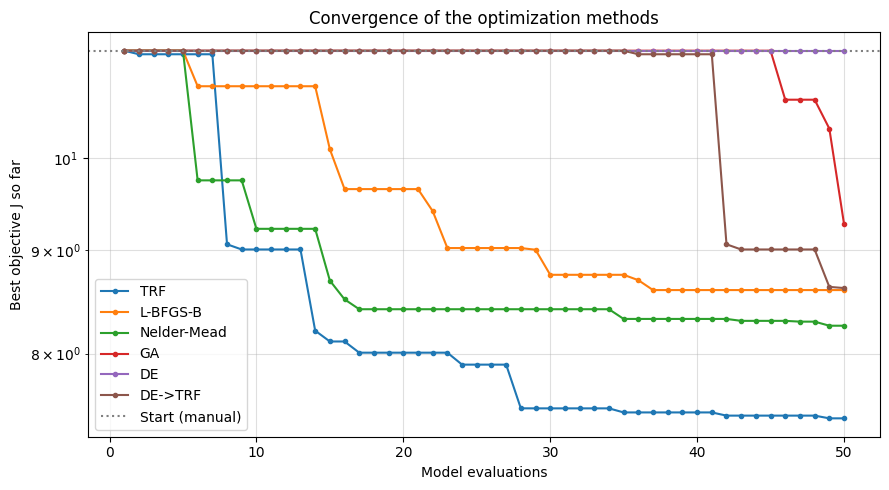

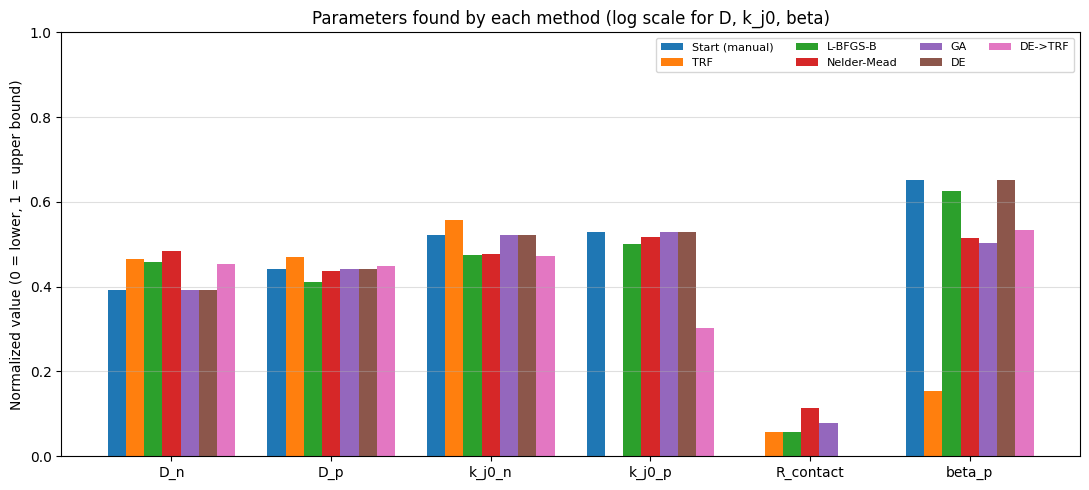

In [5]:
print_summary(result, space.names)
plot_convergence(result, OUT_DIR / "convergence.png")
plot_parameter_comparison(result, objective, OUT_DIR / "parameter_comparison.png")

### 6. Fit on the training tests
Plots measured vs. manual start vs. best optimized model for each training test (voltage, error and, for charge tests, current).

Plotting fit: Charge_1C


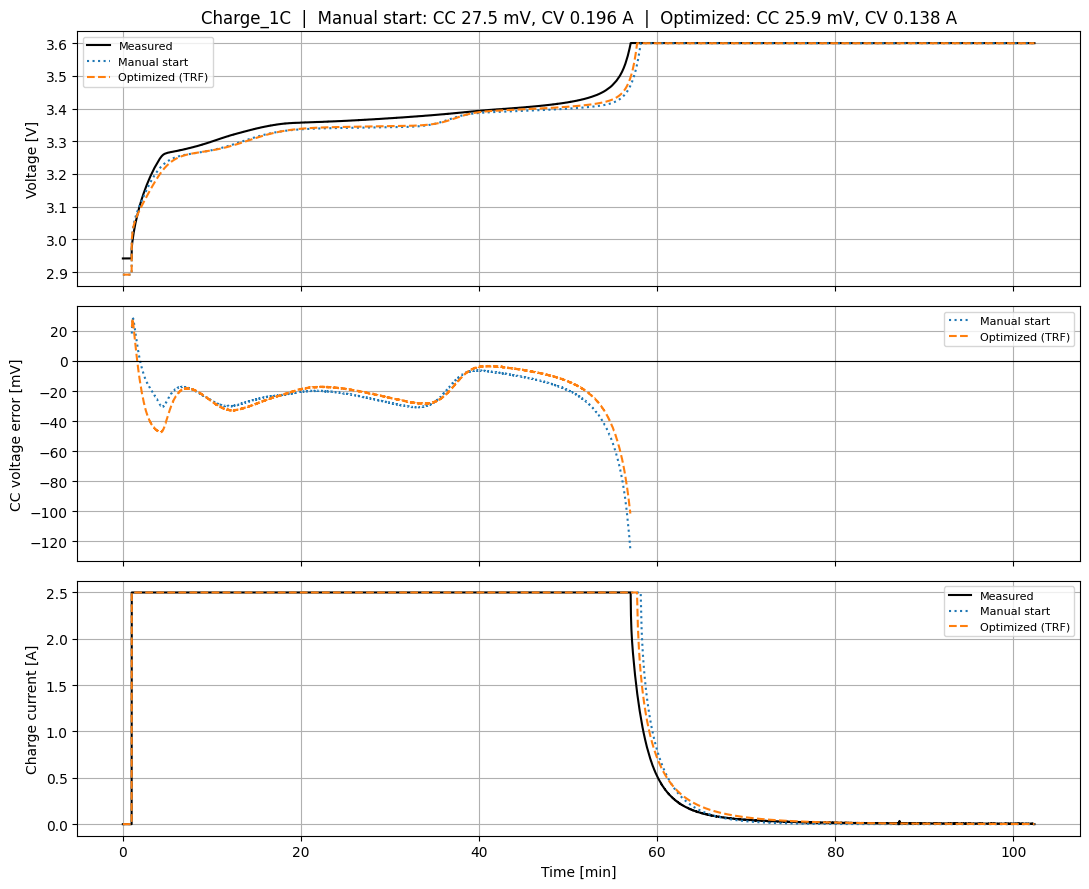

Plotting fit: Charge_2C


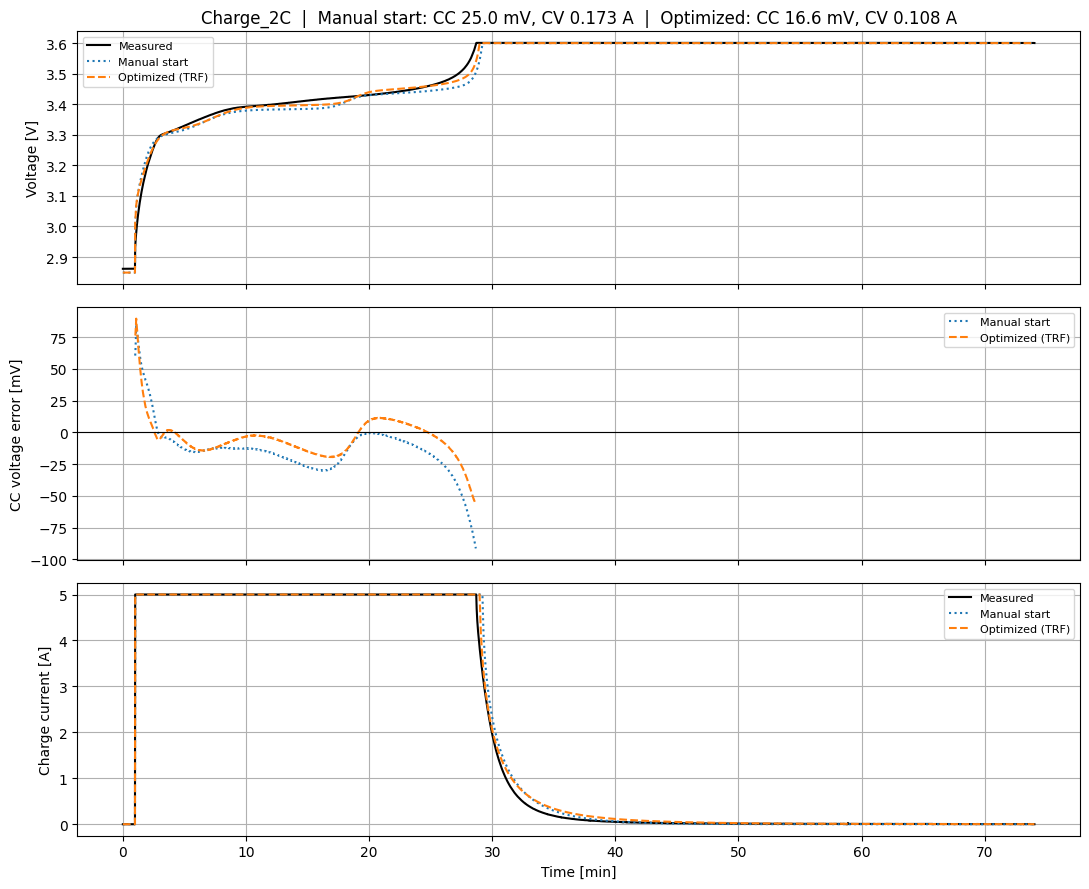

Plotting fit: Charge_3C


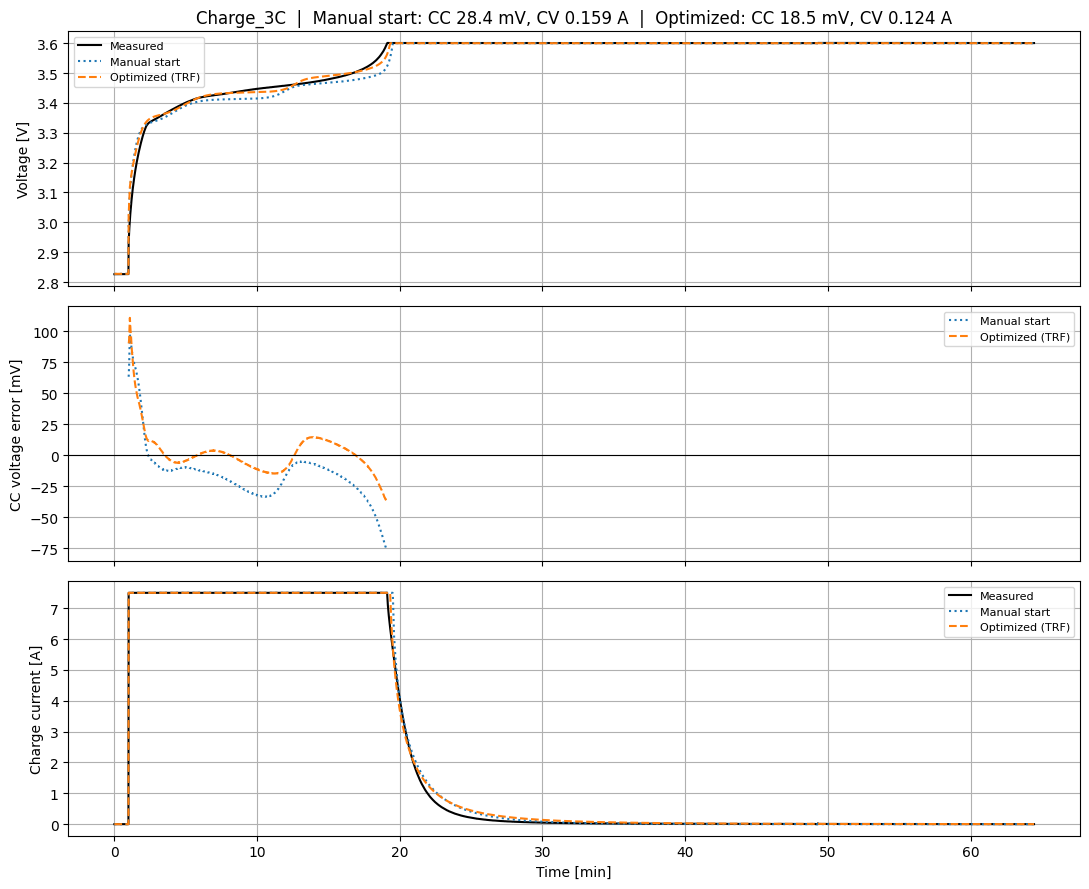

Plotting fit: Charge_4C


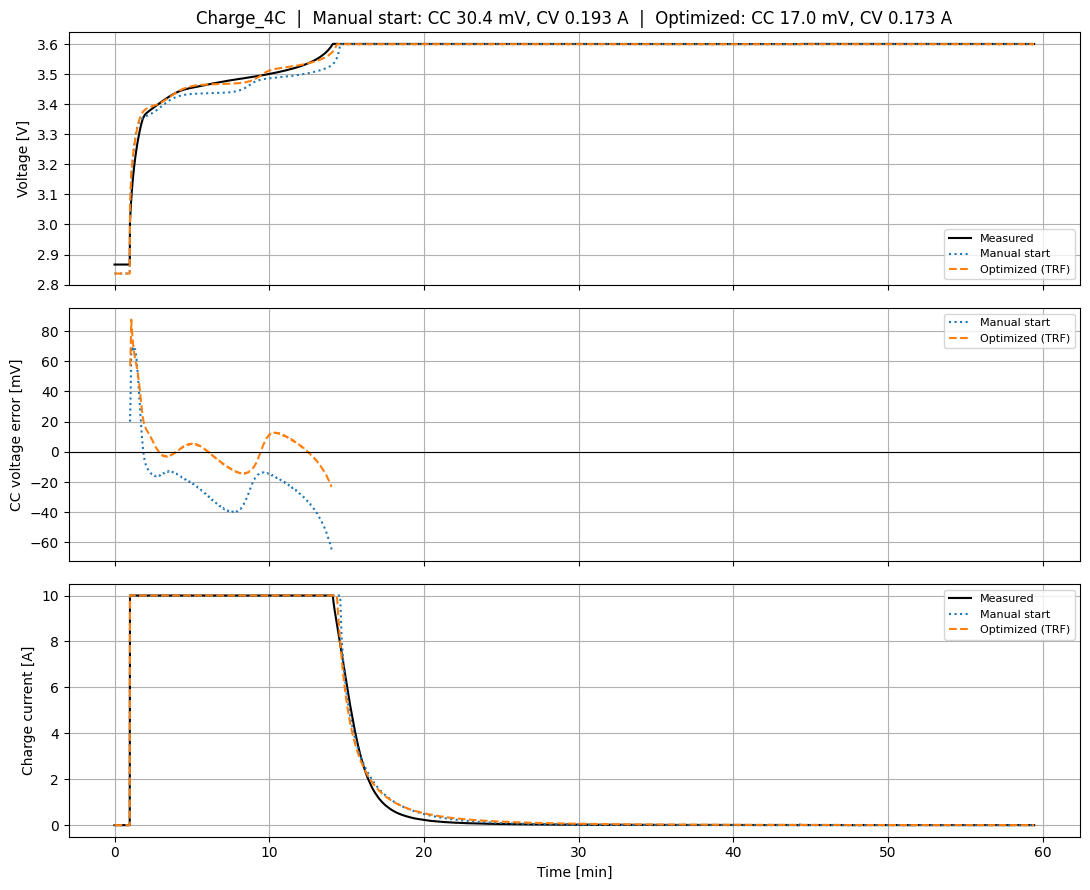

Plotting fit: Discharge_1C


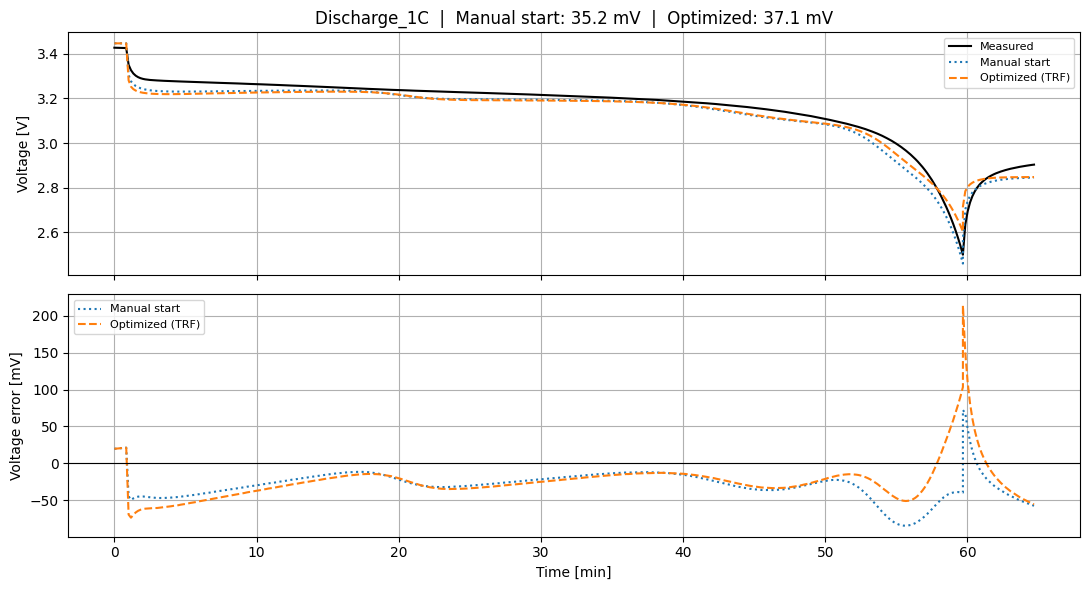

In [6]:
label_opt = f"Optimized ({result.best_method})"
for name in cases:
    print(f"Plotting fit: {name}")
    plot_training_fit(objective, name, result.best_params, result.start_params,
                      label_opt, OUT_DIR / f"fit_{name}.png")

### 7. Validation on HPPC
Simulates the HPPC profile, which was not used in training, with the manual and optimized parameter sets. It reports RMSE, MAE, max error and the RMSE split into rest and pulse periods.

HPPC: 25.20 h, 55460 points, T = 23.2 °C
  running HPPC: Start (manual) ...
    done in 124 s | RMSE 39.7 mV | coverage 100.0 %
  running HPPC: Optimized (TRF) ...
    done in 152 s | RMSE 47.4 mV | coverage 100.0 %

=== HPPC results (validation) ===
                 Coverage [%]  RMSE [mV]  MAE [mV]  Max |err| [mV]  Mean offset [mV]  RMSE rest [mV]  RMSE discharge pulses [mV]  RMSE charge pulses [mV]  Sim time [s]
Start (manual)          100.0      39.74     29.71          296.52              2.97           31.55                       66.52                    47.36        123.88
Optimized (TRF)         100.0      47.39     34.69          630.45              2.77           36.93                       61.87                    77.47        152.21

Start (manual)  ->  Optimized (TRF):
  RMSE [mV]                   :   39.74 ->   47.39 mV  (+19.2 %)
  MAE [mV]                    :   29.71 ->   34.69 mV  (+16.8 %)
  Max |err| [mV]              :  296.52 ->  630.45 mV  (+112.6 %)
  RMSE rest

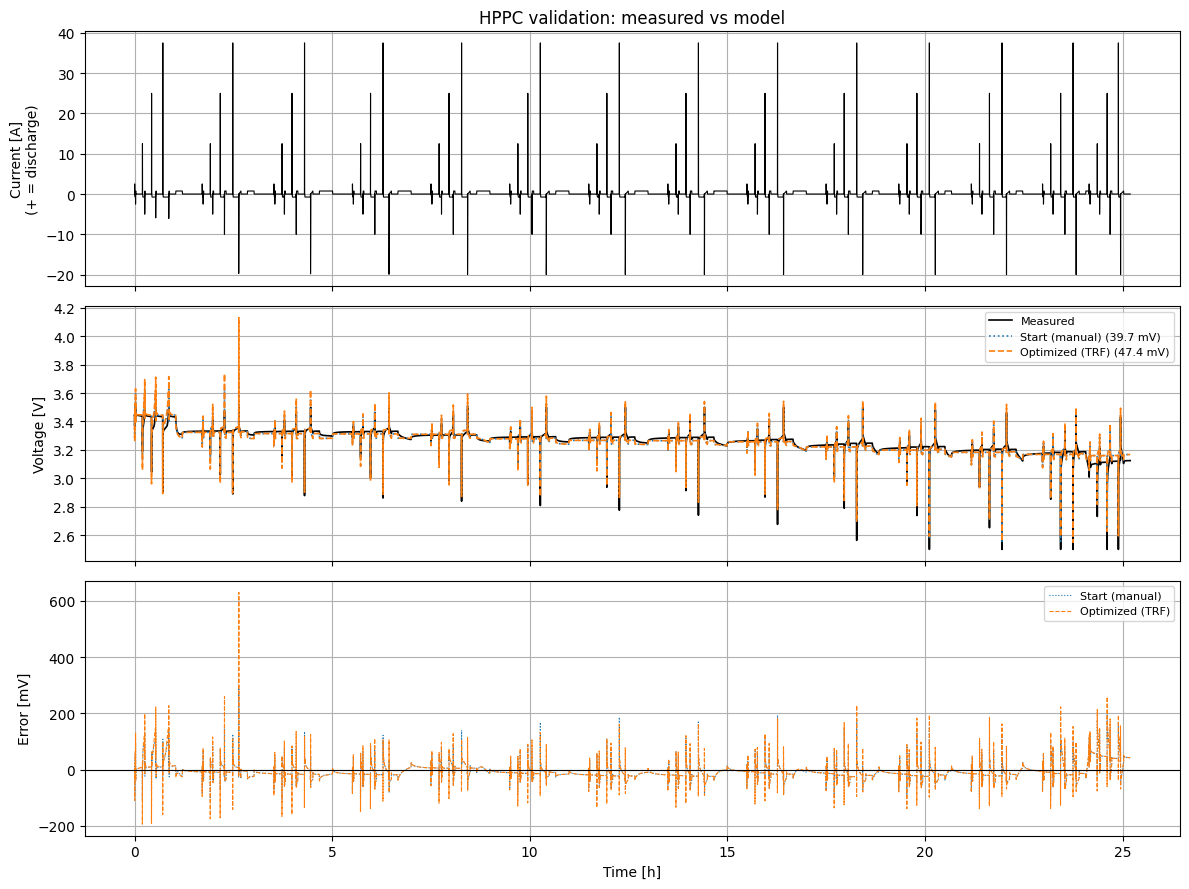

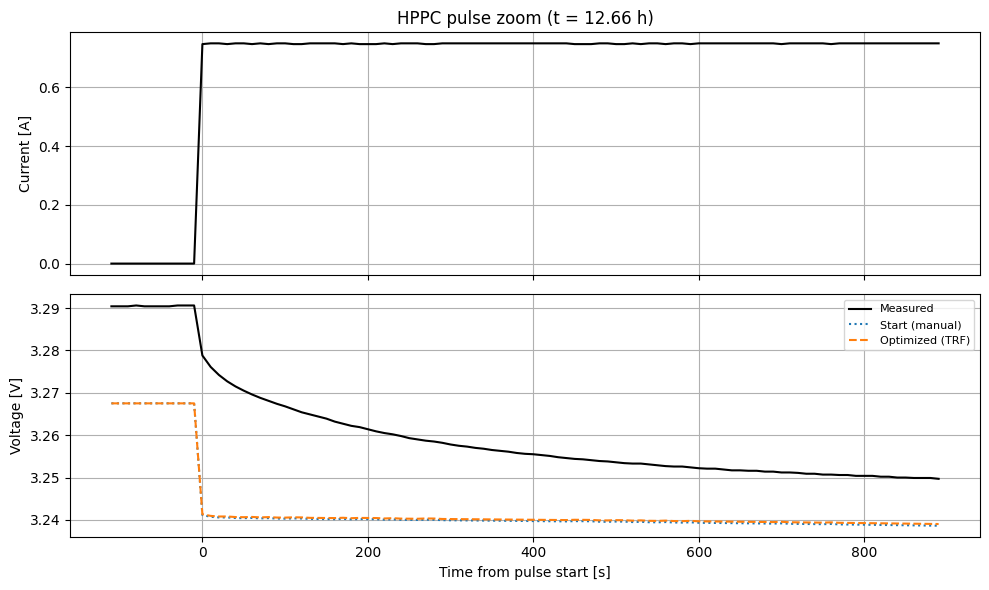

In [7]:
HPPC_ALL_METHODS = False

hppc_cases = {"Start (manual)": result.start_params, label_opt: result.best_params}
if HPPC_ALL_METHODS:
    hppc_cases.update({m: r.best_params for m, r in result.runs.items() if m != result.best_method})

hppc_tbl = run_hppc_check(base_cfg, hppc_cases, DATA_DIR, protocol, OUT_DIR)

### 8. Save results
Saves the optimized parameters, the comparison table, the full evaluation history and the HPPC metrics to `results/task4` for use in Task 5.

In [8]:
path = save_study(result, objective, settings, OUT_DIR, hppc=hppc_tbl.to_dict(orient="index"))
print(f"Saved: {path}")
print("Optimized parameters:", {k: f"{v:.4g}" for k, v in result.best_params.items()})

Saved: K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\optim\results\task4\optimized_parameters.json
Optimized parameters: {'D_n': '2.501e-14', 'D_p': '7.504e-18', 'k_j0_n': '1.307', 'k_j0_p': '0.1005', 'R_contact': '0.0008395', 'beta_p': '0.0204'}
